# Лабораторна 6 - Навчання ознак за допомогою нейронних мереж


**Курс:** Машинне навчання. Частина 2  
**Тиждень:** 6  
**Тема лабораторної:** Навчання ознак за допомогою нейронних мереж

## Цілі лабораторної

1. [Налаштування середовища](#setup): бібліотеки, стиль, відтворюваність
2. [Дані та межі лінійного методу](#part1): задача кіл, провал логістичної регресії
3. [Спроектовані ознаки](#part2): ручне розширення простору ознак
4. [Навчені представлення: 2D-перешийок](#part3): тренування мережі та візуалізація вивченої геометрії
5. [Перехоплення проміжних активацій](#part4): forward hooks та пошарова трансформація даних
6. [Лінійний зонд](#part5): кількісна оцінка лінійної відокремлюваності кожного шару


<a id='setup'></a>
## 1. Налаштування середовища

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Jupyter display
%matplotlib inline

# Reproducibility
np.random.seed(42)

# Add course modules to path
import sys
from pathlib import Path

course_root = Path.cwd()
if 'course' in course_root.parts:
    while course_root.name != 'course' and course_root.parent != course_root:
        course_root = course_root.parent
else:
    course_root = course_root / 'course'

modules_path = course_root / 'modules'
if str(modules_path) not in sys.path:
    sys.path.insert(0, str(modules_path))

# Apply shared colorblind-safe plot style
from plot_style import setup_plot_style, COLORBLIND_PALETTE
setup_plot_style()

import numpy as np
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.datasets import make_circles
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings("ignore")

# Switch the import below to repr_learning_student to test your own implementation
from repr_learning_student import (
    RepresentationNet, train_epoch, extract_activations, linear_probe
)

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

COLORS = ["#4C72B0", "#DD8452"]
CMAP_2 = ListedColormap(["#A8C4E0", "#F5C6A0"])

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)


<a id='part1'></a>
## 2. Дані та межі лінійного методу

### 2.1 Набір даних

Ми будемо працювати з набором **двох концентричних кіл**, класичним прикладом задачі,
де лінійний класифікатор принципово не справляється: ніяка пряма не може розділити
внутрішнє коло від зовнішнього.

Це дозволить нам чітко побачити різницю між:
* **лінійною моделлю** на сирих ознаках: провал;
* **лінійною моделлю** з вручну побудованими нелінійними ознаками: успіх;
* **нейронною мережею**, яка сама вчиться корисним ознакам: успіх без ручної роботи.

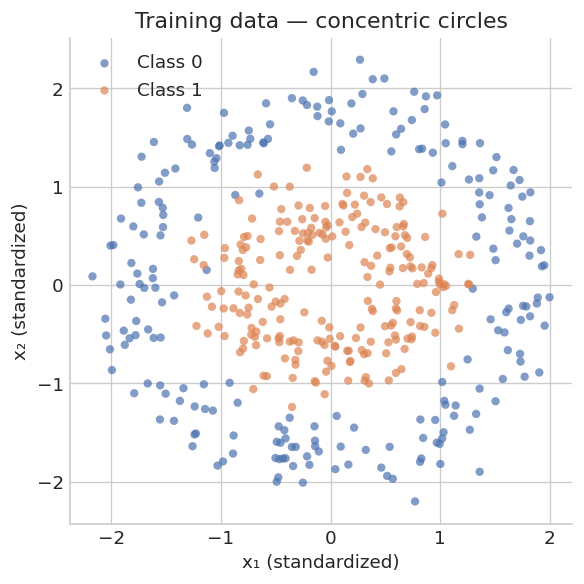

Train samples : 450
Val   samples : 150


In [2]:
# Generate two concentric circles — class 0 = inner, class 1 = outer
X, y = make_circles(n_samples=600, noise=0.12, factor=0.45, random_state=RANDOM_STATE)

X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
)

scaler  = StandardScaler()
X_tr_s  = scaler.fit_transform(X_tr)
X_val_s = scaler.transform(X_val)

fig, ax = plt.subplots(figsize=(5, 5))
for cls in range(2):
    m = y_tr == cls
    ax.scatter(X_tr_s[m, 0], X_tr_s[m, 1], c=COLORS[cls],
               label=f"Class {cls}", alpha=0.7, s=25, edgecolors="none")
ax.set_title("Training data — concentric circles")
ax.set_xlabel("x\u2081 (standardized)")
ax.set_ylabel("x\u2082 (standardized)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Train samples : {len(X_tr_s)}")
print(f"Val   samples : {len(X_val_s)}")

### 2.2 Допоміжна функція візуалізації меж рішення

Наступна функція `plot_boundary` будує межу рішення будь-якого класифікатора,
що приймає масив точок (N, 2) і повертає ймовірність класу 1.  
Ми будемо використовувати її в кожній частині лабораторної.

In [3]:
def plot_boundary(predict_proba_fn, X, y, ax, title, res=280):
    """Plot class-1 probability field and scatter the data points.

    Parameters
    ----------
    predict_proba_fn : callable (N,2) -> (N,) — class-1 probabilities
    X                : np.ndarray shape (N, 2) — 2-D feature matrix to plot
    y                : np.ndarray shape (N,)   — true labels (0 or 1)
    ax               : matplotlib Axes
    title            : str
    res              : int — meshgrid resolution
    """
    x1_lo, x1_hi = X[:, 0].min() - .5, X[:, 0].max() + .5
    x2_lo, x2_hi = X[:, 1].min() - .5, X[:, 1].max() + .5
    xx, yy = np.meshgrid(np.linspace(x1_lo, x1_hi, res),
                         np.linspace(x2_lo, x2_hi, res))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z    = predict_proba_fn(grid).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.35, cmap=CMAP_2, levels=50)
    ax.contour (xx, yy, Z, levels=[0.5], colors="gray", linewidths=1.5)
    for cls in range(2):
        m = y == cls
        ax.scatter(X[m, 0], X[m, 1], c=COLORS[cls], s=20, alpha=0.8,
                   edgecolors="none", label=f"Class {cls}")
    ax.set_title(title)
    ax.set_xlabel("x\u2081")
    ax.set_ylabel("x\u2082")
    ax.legend(fontsize=9)

### 2.3 Логістична регресія на сирих ознаках

Логістична регресія будує **лінійну** межу рішення в просторі ознак.  
Для задачі кіл така межа є принципово недостатньою; жодна пряма не відокремлює
внутрішнє коло від зовнішнього.

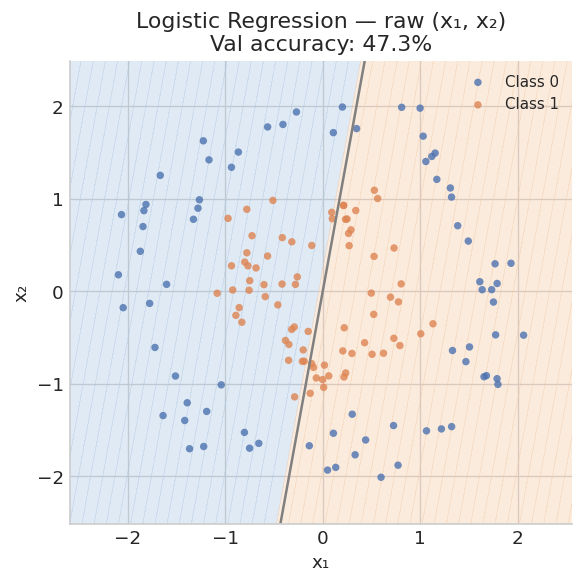

Validation accuracy (raw features): 47.3%
Expected: ~50% — no better than random guessing.


In [4]:
lr_raw = LogisticRegression(random_state=RANDOM_STATE)
lr_raw.fit(X_tr_s, y_tr)
acc_raw = accuracy_score(y_val, lr_raw.predict(X_val_s))

fig, ax = plt.subplots(figsize=(5, 5))
plot_boundary(
    lambda g: lr_raw.predict_proba(g)[:, 1],
    X_val_s, y_val, ax,
    f"Logistic Regression — raw (x\u2081, x\u2082)\nVal accuracy: {acc_raw:.1%}"
)
plt.tight_layout()
plt.show()

print(f"Validation accuracy (raw features): {acc_raw:.1%}")
print("Expected: ~50% — no better than random guessing.")

<a id='part2'></a>
## 3. Спроектовані ознаки

Якщо ми **вручну** розширимо простір ознак нелінійними комбінаціями,
межа рішення в розширеному просторі виявляється лінійною, хоча у вихідному
2D-просторі вона виглядає як крива.

Після додавання нових ознак будемо використовувати:

$$\phi(x_1, x_2) = [\, x_1,\; x_2,\; x_1^2,\; x_2^2,\; x_1 x_2 \,]$$

Логістична регресія в цьому 5D-просторі фактично вчить **квадратичну** межу у 2D.
Це і є принцип **kernel trick** та ручного feature engineering.

> **Ключовий момент:** ми самі вирішили, які нелінійні ознаки корисні.  
> Нейронна мережа навчиться це сама.

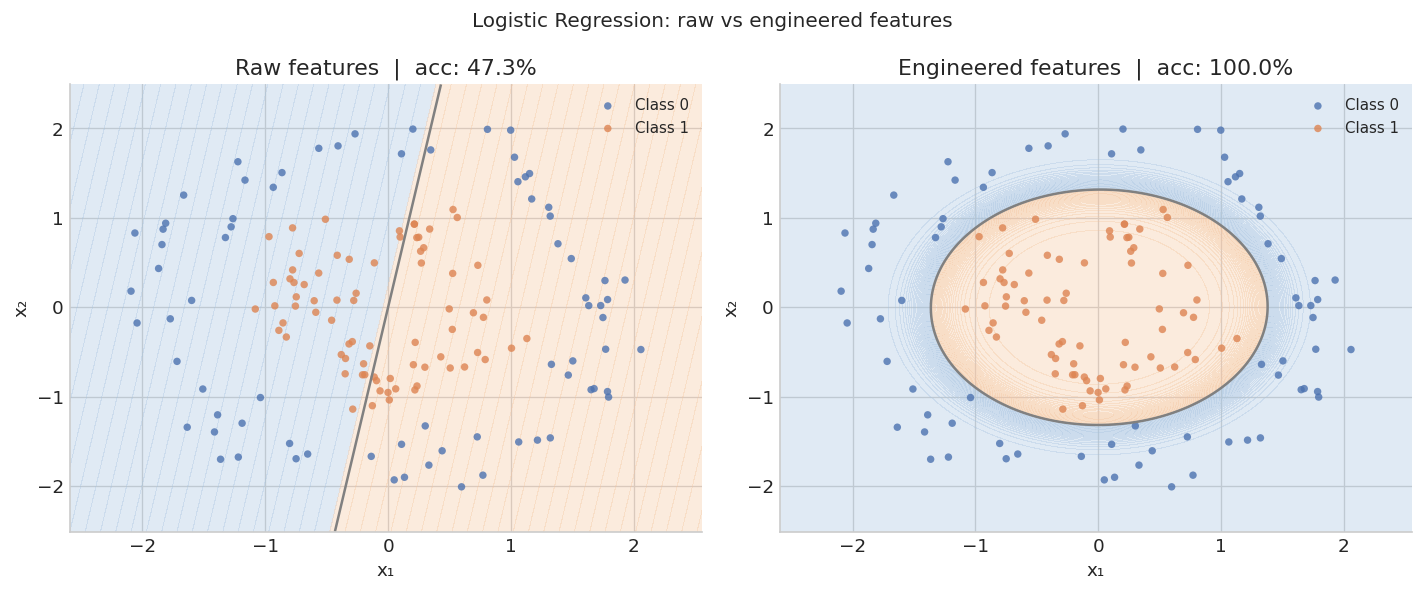

Raw features accuracy      : 47.3%
Engineered features acc    : 100.0%


In [5]:
def engineer_features(X):
    """Manually craft 5 non-linear features: [x1, x2, x1^2, x2^2, x1*x2]."""
    x1, x2 = X[:, 0], X[:, 1]
    return np.column_stack([x1, x2, x1**2, x2**2, x1 * x2])

X_tr_eng  = engineer_features(X_tr_s)
X_val_eng = engineer_features(X_val_s)

lr_eng = LogisticRegression(random_state=RANDOM_STATE)
lr_eng.fit(X_tr_eng, y_tr)
acc_eng = accuracy_score(y_val, lr_eng.predict(X_val_eng))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

plot_boundary(
    lambda g: lr_raw.predict_proba(g)[:, 1],
    X_val_s, y_val, axes[0],
    f"Raw features  |  acc: {acc_raw:.1%}"
)

plot_boundary(
    lambda g: lr_eng.predict_proba(engineer_features(g))[:, 1],
    X_val_s, y_val, axes[1],
    f"Engineered features  |  acc: {acc_eng:.1%}"
)

plt.suptitle("Logistic Regression: raw vs engineered features", fontsize=12)
plt.tight_layout()
plt.show()

print(f"Raw features accuracy      : {acc_raw:.1%}")
print(f"Engineered features acc    : {acc_eng:.1%}")

<a id='part3'></a>
## 4. Навчені представлення: 2D-перешийок

### 4.1 Архітектура мережі

Замість того щоб конструювати ознаки вручну, ми навчимо нейронну мережу, яка сама
трансформує дані у зручний для класифікації простір.

Ключовий прийом: встановимо **2-нейронний прихований шар** (bottleneck); тоді
навчене представлення матиме розмірність 2 і ми зможемо побачити його напряму
на площині, без будь-якого зниження розмірності.

```
Input(2)
  → Linear(2 → 32) → ReLU     # act1: широкий прихований шар
  → Linear(32 → 2) → ReLU     # act2: вузький «перешийок» (2-D)
  → Linear(2 → n_classes)     # класифікаційна голова
```

### 4.2 Завдання для студентів

**TODO 1: `RepresentationNet.encode(x)`**  
Реалізуйте прямий прохід через прихованi шари (без класифікаційної голови).  
Це `fc1 → act1 → fc2 → act2`.  
Метод `forward` вже реалізований і використовує `encode`; не змінюйте його.

**TODO 2: `train_epoch(model, optimizer, X_t, y_t)`**  
Реалізуйте один крок градієнтного спуску: нуль-градієнти, forward, cross-entropy, backward, крок оптимізатора. Поверніть скалярне значення функції втрат.

In [6]:
torch.manual_seed(RANDOM_STATE)

model     = RepresentationNet(input_dim=2, hidden_dim=32, bottleneck_dim=2, n_classes=2)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Convert numpy arrays to PyTorch tensors
X_t = torch.tensor(X_tr_s, dtype=torch.float32)
y_t = torch.tensor(y_tr,   dtype=torch.long)

N_EPOCHS = 800
losses   = []

for epoch in range(N_EPOCHS):
    loss = train_epoch(model, optimizer, X_t, y_t)   # <-- your implementation
    losses.append(loss)

# Evaluate on validation set
X_val_t = torch.tensor(X_val_s, dtype=torch.float32)
model.eval()
with torch.no_grad():
    preds_val = model(X_val_t).argmax(dim=1).numpy()
acc_nn = accuracy_score(y_val, preds_val)

print(f"Final training loss : {losses[-1]:.4f}")
print(f"Validation accuracy : {acc_nn:.1%}")

Final training loss : 0.2434
Validation accuracy : 100.0%


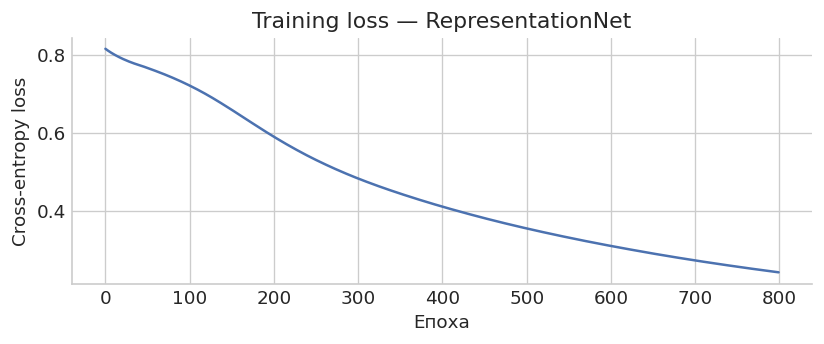

In [7]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(losses, color=COLORS[0], lw=1.5)
ax.set_xlabel("Епоха")
ax.set_ylabel("Cross-entropy loss")
ax.set_title("Training loss — RepresentationNet")
plt.tight_layout()
plt.show()

### 4.3 Візуалізація навченого представлення

Тепер скористаємося методом `encode()`, який повертає координати кожної точки
у 2D-просторі перешийку. 
Порівняємо межу рішення у вхідному просторі з навченим представленням.

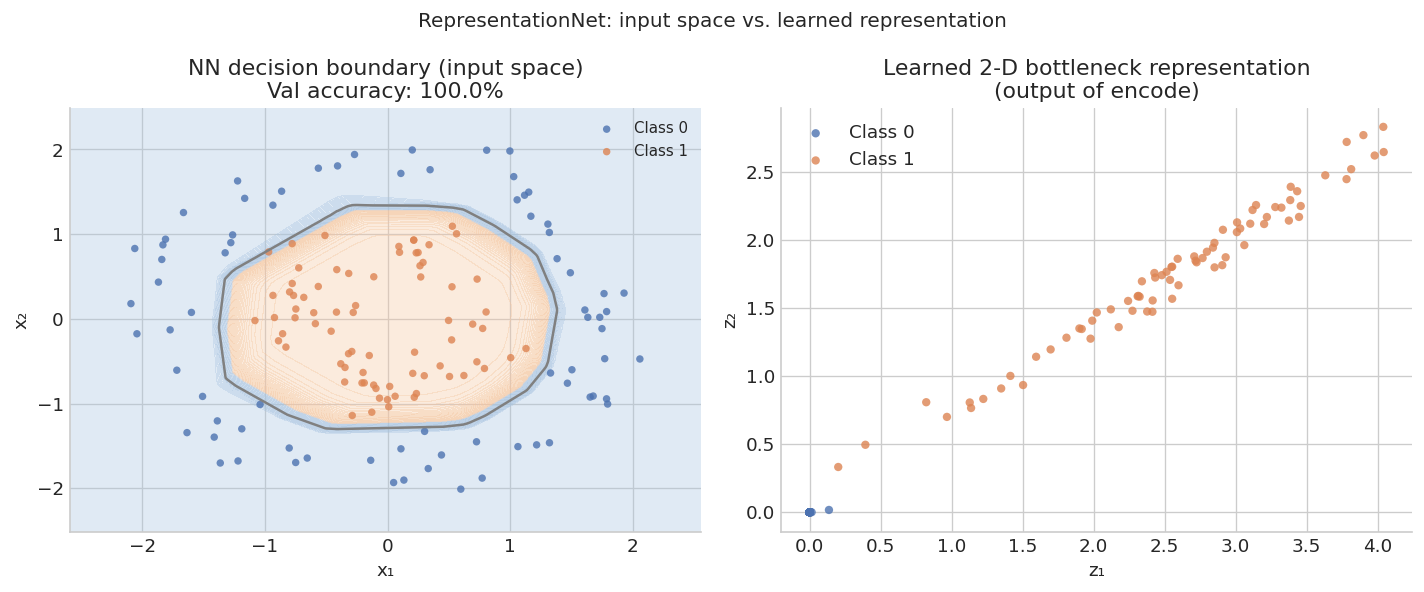

In [8]:
# Get the 2-D bottleneck representation for the validation set
model.eval()
with torch.no_grad():
    Z_val = model.encode(X_val_t).numpy()   # shape (N_val, 2)

def nn_proba(X_np):
    """Class-1 probability from the trained network."""
    t = torch.tensor(X_np, dtype=torch.float32)
    model.eval()
    with torch.no_grad():
        return torch.softmax(model(t), dim=1)[:, 1].numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: decision boundary in the original input space
plot_boundary(
    nn_proba, X_val_s, y_val, axes[0],
    f"NN decision boundary (input space)\nVal accuracy: {acc_nn:.1%}"
)

# Right: scatter of the learned 2-D representation
for cls in range(2):
    m = y_val == cls
    axes[1].scatter(Z_val[m, 0], Z_val[m, 1], c=COLORS[cls],
                    label=f"Class {cls}", alpha=0.8, s=25, edgecolors="none")
axes[1].set_title("Learned 2-D bottleneck representation\n(output of encode)")
axes[1].set_xlabel("z\u2081")
axes[1].set_ylabel("z\u2082")
axes[1].legend()

plt.suptitle("RepresentationNet: input space vs. learned representation", fontsize=12)
plt.tight_layout()
plt.show()

<a id='part4'></a>
## 5. Перехоплення проміжних активацій

### 5.1 Що таке forward hook?

PyTorch дозволяє реєструвати **хуки** (hooks) на будь-якому шарі мережі.  
Forward hook: це функція, яку PyTorch автоматично викликає під час прямого
проходу щоразу, коли через цей шар проходять дані.  
Хук отримує три аргументи: сам шар, його вхід та вихід.

```python
def hook_fn(module, input, output):
    # output: activations of this layer for the current batch
    captured['output'] = output.detach()

handle = layer.register_forward_hook(hook_fn)
# ... run forward pass ...
handle.remove()   # завжди прибираємо хук після використання
```

### 5.2 Завдання для студентів

**TODO 3: `extract_activations(model, X_tensor, layer)`**  
Реалізуйте функцію, яка реєструє forward hook на заданому шарі `layer`,
запускає прямий прохід моделі і повертає перехоплені активації у вигляді
NumPy-масиву. Не забудьте видалити хук після використання.

Нижче ми будемо перехоплювати активації після `model.act1` (32-вимірний шар)
і після `model.act2` (2-вимірний перешийок).

In [9]:
# Extract activations at two stages of the network using your extract_activations
act1_val = extract_activations(model, X_val_t, model.act1)  # shape (N_val, 32)
act2_val = extract_activations(model, X_val_t, model.act2)  # shape (N_val, 2)

print(f"act1 activations shape : {act1_val.shape}  (32-D hidden layer)")
print(f"act2 activations shape : {act2_val.shape}  (2-D bottleneck)")

# Sanity check: act2 should match encode() output
max_diff = np.abs(act2_val - Z_val).max()
print(f"\nMax diff act2 vs encode: {max_diff:.2e}  (should be ~0)")

act1 activations shape : (150, 32)  (32-D hidden layer)
act2 activations shape : (150, 2)  (2-D bottleneck)

Max diff act2 vs encode: 0.00e+00  (should be ~0)


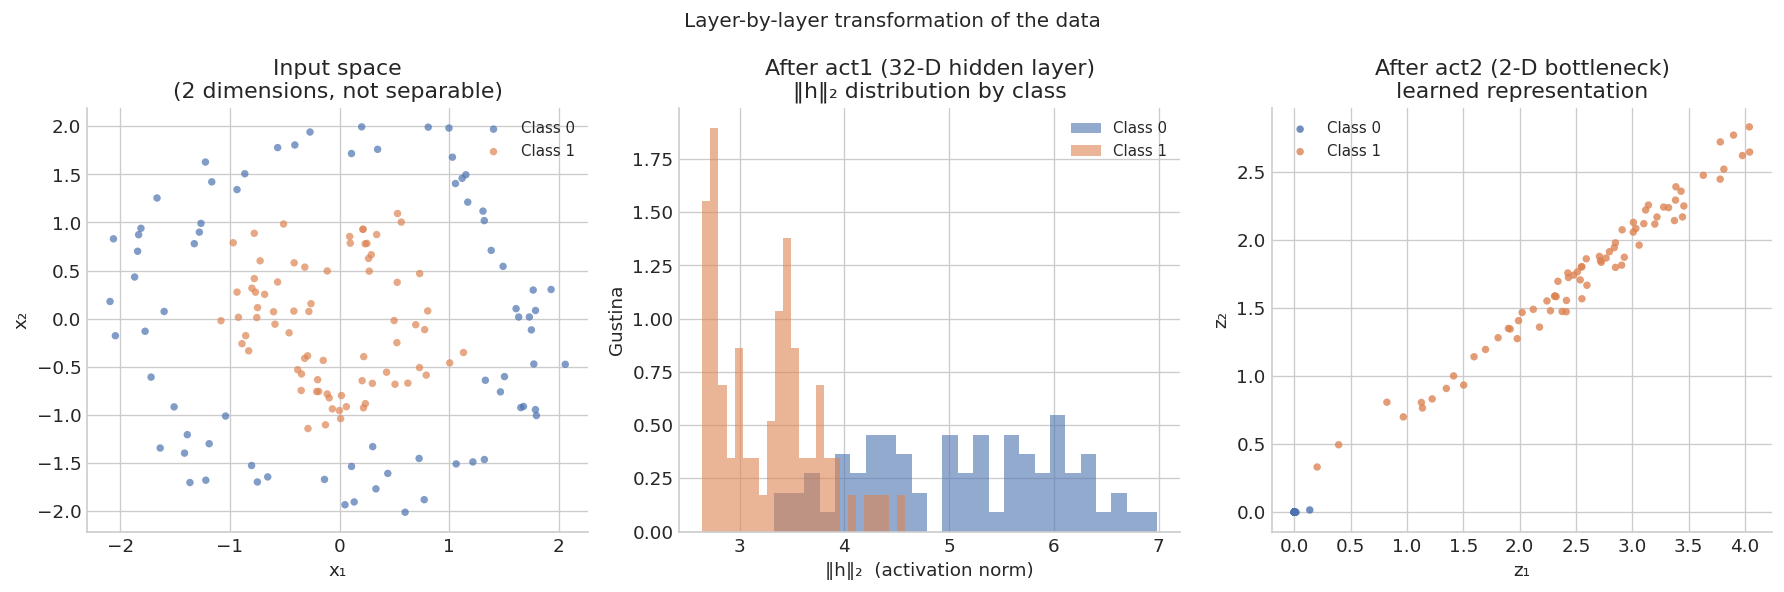

In [10]:
# Compute the L2 norm of each sample's 32-D activation vector
norms_act1 = np.linalg.norm(act1_val, axis=1)   # scalar per sample

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Panel 1 — raw input (not separable)
for cls in range(2):
    m = y_val == cls
    axes[0].scatter(X_val_s[m, 0], X_val_s[m, 1], c=COLORS[cls],
                    label=f"Class {cls}", alpha=0.7, s=20, edgecolors="none")
axes[0].set_title("Input space\n(2 dimensions, not separable)")
axes[0].set_xlabel("x\u2081")
axes[0].set_ylabel("x\u2082")
axes[0].legend(fontsize=9)

# Panel 2 — L2-norm of act1 (32-D hidden layer) by class
for cls in range(2):
    m = y_val == cls
    axes[1].hist(norms_act1[m], bins=25, alpha=0.6, color=COLORS[cls],
                 label=f"Class {cls}", density=True)
axes[1].set_title("After act1 (32-D hidden layer)\n\u2016h\u2016\u2082 distribution by class")
axes[1].set_xlabel("\u2016h\u2016\u2082  (activation norm)")
axes[1].set_ylabel("Gustina")
axes[1].legend(fontsize=9)

# Panel 3 — 2-D bottleneck (act2, directly plottable)
for cls in range(2):
    m = y_val == cls
    axes[2].scatter(act2_val[m, 0], act2_val[m, 1], c=COLORS[cls],
                    label=f"Class {cls}", alpha=0.8, s=20, edgecolors="none")
axes[2].set_title("After act2 (2-D bottleneck)\nlearned representation")
axes[2].set_xlabel("z\u2081")
axes[2].set_ylabel("z\u2082")
axes[2].legend(fontsize=9)

plt.suptitle("Layer-by-layer transformation of the data", fontsize=12)
plt.tight_layout()
plt.show()

<a id='part5'></a>
## 6. Лінійний зонд

### 6.1 Що вимірює лінійний зонд?

**Лінійний зонд** (linear probe): стандартний інструмент для кількісної оцінки
якості представлень: ми навчаємо просту **логістичну регресію** на "заморожених"
активаціях кожного шару і вимірюємо її точність.

* Якщо лінійний класифікатор добре справляється з активаціями певного шару, це
  означає, що цей шар вже організував дані у **лінійно відокремлюваний** спосіб.
* Порівнюючи зонди на різних шарах, ми бачимо, **коли** і **наскільки** 
  мережа навчається корисним ознакам.

### 6.2 Завдання для студентів

**TODO 4: `linear_probe(h_train, y_train, h_val, y_val)`**  
Реалізуйте функцію: навчіть `LogisticRegression` на тренувальних представленнях
і поверніть `(train_acc, val_acc)` для обох розбивок.

In [11]:
# Extract training-set activations as well (needed to fit the probe)
X_tr_t   = torch.tensor(X_tr_s,  dtype=torch.float32)
act1_tr  = extract_activations(model, X_tr_t,  model.act1)
act2_tr  = extract_activations(model, X_tr_t,  model.act2)

# Run a linear probe on each representation
results = {}

tr_acc, vl_acc = linear_probe(X_tr_s, y_tr, X_val_s, y_val)
results["Input (2-D)"] = (tr_acc, vl_acc)

tr_acc, vl_acc = linear_probe(act1_tr, y_tr, act1_val, y_val)
results["After act1 (32-D)"] = (tr_acc, vl_acc)

tr_acc, vl_acc = linear_probe(act2_tr, y_tr, act2_val, y_val)
results["After act2 (2-D)"] = (tr_acc, vl_acc)

print(f"{'Representation':<25}  {'Train acc':>10}  {'Val acc':>10}")
print("-" * 50)
for name, (tr, vl) in results.items():
    print(f"{name:<25}  {tr:>9.1%}  {vl:>9.1%}")

Representation              Train acc     Val acc
--------------------------------------------------
Input (2-D)                    52.0%      47.3%
After act1 (32-D)              98.9%     100.0%
After act2 (2-D)               98.0%      98.7%


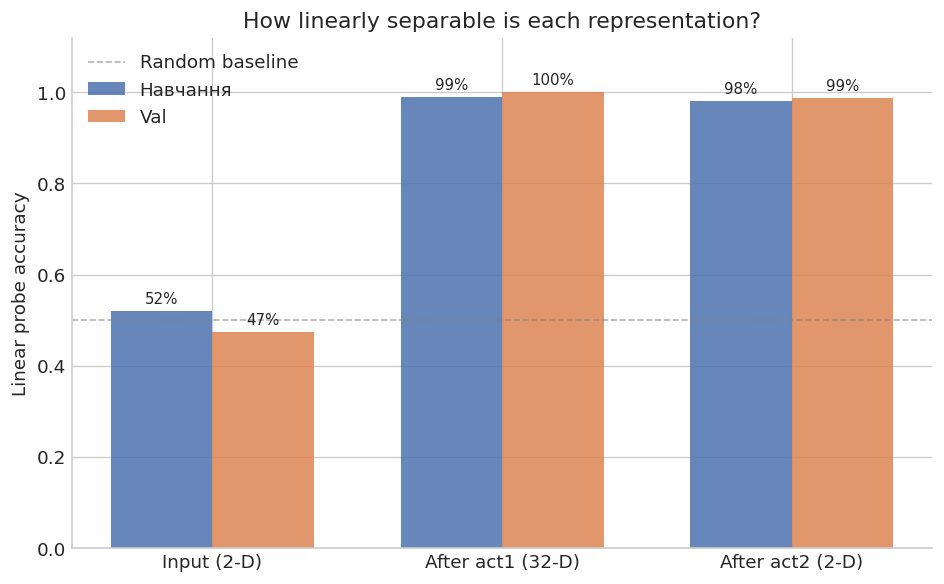

In [12]:
labels     = list(results.keys())
train_accs = [v[0] for v in results.values()]
val_accs   = [v[1] for v in results.values()]

x     = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width / 2, train_accs, width,
               label="Навчання", color=COLORS[0], alpha=0.85)
bars2 = ax.bar(x + width / 2, val_accs,   width,
               label="Val",   color=COLORS[1], alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1.12)
ax.set_ylabel("Linear probe accuracy")
ax.set_title("How linearly separable is each representation?")
ax.axhline(0.5, color="gray", lw=1, ls="--", alpha=0.6, label="Random baseline")
ax.legend()

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{bar.get_height():.0%}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

---
## Підсумок

| Тема | Ключовий висновок |
|---|---|
| **Лінійна модель на сирих ознаках** | Не справляється з задачею кіл: ~50% точності, межа є прямою |
| **Спроектовані ознаки** | Ручне додавання $x_1^2, x_2^2, x_1 x_2$ дозволяє лінійній моделі навчитись круговій межі |
| **Навчені представлення** | Нейромережа сама вчиться перетворювати дані у зручний простір без ручної роботи |
| **2-D перешийок** | Якщо bottleneck_dim=2, навчену геометрію можна побачити напряму на scatter plot |
| **Forward hooks** | Дозволяють перехоплювати активації будь-якого шару без зміни архітектури моделі |
| **Лінійний зонд** | Точність лінійного класифікатора на активаціях вимірює ступінь лінійної відокремлюваності: зростає з глибиною |
